# cfd-perf Demo -- Steady RANS Strong-Scaling Estimator

Industrial-grade example: **20M-cell hex-dominant RANS mesh** with 5 pilot
measurements showing realistic non-linear scaling degradation.

1. Define mesh metadata and pilot benchmark data
2. Analyze the mesh and auto-fit the scaling model
3. Run optimization in **efficiency-driven** and **deadline-driven** modes
4. Inspect candidate tables with Rich
5. Generate professional scaling plots (using the `plotting` library)
6. Export JSON, CSV, PNG, and SLURM snippet

**Prerequisites**

```bash
cd tools/cfd-perf && pip install -e ".[dev]"
```

## Mathematical formulation

### Strong-scaling model

Given a baseline pilot measurement at $ N_{c_0} $ cores with wall-time per
iteration $ T_0 $, the predicted time per iteration at $ N_c $ cores is

$$
T(N_c) \;=\; T_0 \left[\; \frac{N_{c_0}}{N_c} \;+\; \beta\;\left(1 - \frac{N_{c_0}}{N_c}\right) \;\right]
$$

where $ \beta \in [0.1,\; 0.4] $ is the communication overhead fraction:

- $ \beta = 0 $: ideal (linear) scaling
- $ \beta = 1 $: no speedup at all

### Derived metrics

| Metric | Formula |
|:---|:---|
| Speedup | $ S(N_c) = \dfrac{T_0}{T(N_c)} $ |
| Parallel efficiency | $ E(N_c) = \dfrac{S(N_c)}{N_c / N_{c_0}} $ |
| Efficiency loss | $ \ell(N_c) = 1 - E(N_c) $ |
| Total runtime | $ t_{\mathrm{wall}}(N_c) = T(N_c) \;\times\; N_{\mathrm{iter}} $ |

### Memory model

Total memory is assumed proportional to the number of cells and independent of
core count (fixed mesh, no AMR):

$$
\mathrm{RAM}_{\mathrm{total}} = m_{\mathrm{cell}} \;\times\; N_{\mathrm{cells}}
\qquad\qquad
\mathrm{RAM}_{\mathrm{core}}(N_c) = \frac{\mathrm{RAM}_{\mathrm{total}}}{N_c}
$$

where $ m_{\mathrm{cell}} $ is estimated from the pilot baseline:
$ m_{\mathrm{cell}} = \mathrm{RAM}_0 \;/\; N_{\mathrm{cells}} $.

### Beta fitting

When $ \geq 2 $ pilot points are available, $ \beta $ is fitted by ordinary
least squares.  Defining $ r_i = N_{c_0} / N_{c_i} $ and
$ a_i = T_0\,(1 - r_i) $, the closed-form solution is

$$
\hat\beta \;=\; \frac{\sum_i a_i \left(T_i^{\mathrm{meas}} - T_0\,r_i\right)}
                      {\sum_i a_i^2}
\qquad\text{clamped to } [0.1,\;0.4]
$$

With a single pilot point, the default $ \beta = 0.25 $ is used.

### Hard constraints

A candidate core count $ N_c $ is **rejected** if either condition is violated:

$$
\frac{N_{\mathrm{cells}}}{N_c} \;\geq\; N_{\mathrm{cells/core}}^{\min}
\qquad\qquad
\mathrm{RAM}_{\mathrm{core}}(N_c) \;\geq\; \mathrm{RAM}_{\mathrm{core}}^{\min}
$$

### Optimization modes

| Mode | Objective | Selection rule |
|:---|:---|:---|
| **Efficiency** | $ \ell(N_c) \leq \ell_{\max} $ | largest feasible $ N_c $ |
| **Deadline** | $ t_{\mathrm{wall}}(N_c) \leq t_{\mathrm{deadline}} $ | smallest feasible $ N_c $ |

In [27]:
import sys
from pathlib import Path

PLOTTING_PATH = str(Path("../../scripts/post/plot").resolve())
if PLOTTING_PATH not in sys.path:
    sys.path.insert(0, PLOTTING_PATH)

## 1. Sample input data

20M-cell hex-dominant mesh (typical external aero or turbomachinery RANS case).
Five pilot points measured on a production cluster, showing realistic communication
overhead growth -- note how T/iter flattens out beyond 384 cores.

In [18]:
import json
import tempfile

workdir = Path(tempfile.mkdtemp(prefix="cfd_perf_demo_"))

mesh_data = {
    "num_cells": 20_000_000,
    "num_faces": 61_200_000,
    "cell_type_distribution": {"hex": 0.78, "prism": 0.14, "tet": 0.06, "pyramid": 0.02},
}

# Pilot data: 5 points with realistic non-linear degradation.
# beta implied per point: ~0.13, ~0.16, ~0.19, ~0.21
# The single-beta model will fit an average around 0.17-0.18.
pilot_data = {
    "n_iterations": 12_000,
    "points": [
        {"cores":  48, "time_per_iter_s": 3.85, "peak_ram_total_gb": 142.0},
        {"cores":  96, "time_per_iter_s": 2.18, "peak_ram_total_gb": 142.0},
        {"cores": 192, "time_per_iter_s": 1.41, "peak_ram_total_gb": 143.0},
        {"cores": 384, "time_per_iter_s": 1.12, "peak_ram_total_gb": 144.0},
        {"cores": 576, "time_per_iter_s": 1.05, "peak_ram_total_gb": 145.0},
    ],
}

mesh_path = workdir / "mesh.json"
pilot_path = workdir / "pilot.json"
mesh_path.write_text(json.dumps(mesh_data, indent=2))
pilot_path.write_text(json.dumps(pilot_data, indent=2))

print(f"Working directory: {workdir}")

Working directory: /tmp/cfd_perf_demo__mn6wmti


## 2. Analyze mesh

In [19]:
from cfd_perf.benchmark.ingest import load_pilot
from cfd_perf.mesh.analyzer import analyze_mesh
from cfd_perf.cli.console import print_mesh_stats

pilot = load_pilot(pilot_path)
mesh = analyze_mesh(mesh_path, pilot_baseline=pilot.baseline)

print_mesh_stats(mesh)

                          Mesh Analysis                          
┏━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property         ┃                                      Value ┃
┡━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Cells            │                                 20,000,000 │
│ Faces            │                                 61,200,000 │
│ Cell types       │ hex: 78%  prism: 14%  tet: 6%  pyramid: 2% │
│ Mem / cell       │                                    7,624 B │
│ Total RAM (est.) │                                   142.0 GB │
└──────────────────┴────────────────────────────────────────────┘

## 3. Fit scaling model (beta)

Auto-fit from 5 pilot points by least squares.  The per-point implied betas
range from 0.13 to 0.21, reflecting increasing communication overhead.
The fit averages this into a single effective beta.

In [20]:
from cfd_perf.models.strong_scaling import fit_beta
from cfd_perf.cli.console import print_fit_result

params = fit_beta(pilot)
print_fit_result(params, pilot)

      Scaling Model Fit       
┏━━━━━━━━━━━━━━━━━┳━━━━━━━━━━┓
┃ Property        ┃    Value ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━━━━━━┩
│ Beta            │ 0.181555 │
│ Source          │   fitted │
│ Baseline cores  │       48 │
│ Baseline T/iter │  3.850 s │
│ Iterations      │   12,000 │
│ Pilot points    │        5 │
└─────────────────┴──────────┘

              Pilot Data              
┏━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Cores ┃ T/iter (s) ┃ Peak RAM (GB) ┃
┡━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│    48 │      3.850 │         142.0 │
│    96 │      2.180 │         142.0 │
│   192 │      1.410 │         143.0 │
│   384 │      1.120 │         144.0 │
│   576 │      1.050 │         145.0 │
└───────┴────────────┴───────────────┘

## 4. Optimize -- Efficiency-driven (max 25% loss)

Select the largest core count where parallel efficiency loss stays below 25%.

In [21]:
from cfd_perf.constraints.config import HardConstraints
from cfd_perf.optimizer.selector import optimize
from cfd_perf.cli.console import print_optimization_result

constraints = HardConstraints(min_cells_per_core=100_000, min_ram_per_core_gb=0.5)

result_eff = optimize(
    mesh, pilot, params,
    mode="efficiency",
    max_efficiency_loss=0.25,
    cores_max=1024,
    stride=48,
    constraints=constraints,
)

print_optimization_result(result_eff)

╭────────────────────────────────────── Optimal Configuration (EFFICIENCY) ───────────────────────────────────────╮
│ Cores:           96                                                                                             │
│ Time / iter:     2.274 s                                                                                        │
│ Total runtime:   7.58 h                                                                                         │
│ Speedup:         1.69x                                                                                          │
│ Efficiency:      84.6%                                                                                          │
│ Eff. loss:       15.4%                                                                                          │
│ RAM total:       142.0 GB                                                                                       │
│ RAM / core:      1.48 GB                                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

                                 Accepted Candidates (2)                                 
┏━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━┓
┃ Cores ┃ T/iter (s) ┃ Runtime (h) ┃ Speedup ┃ Eff (%) ┃ Loss (%) ┃ RAM/core (GB) ┃     ┃
┡━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━┩
│    48 │      3.850 │       12.83 │    1.00 │   100.0 │      0.0 │          2.96 │     │
│    96 │      2.274 │        7.58 │    1.69 │    84.6 │     15.4 │          1.48 │ <-- │
└───────┴────────────┴─────────────┴─────────┴─────────┴──────────┴───────────────┴─────┘

                      Rejected (19)                      
┏━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Cores ┃ Reasons                                       ┃
┡━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│   144 │ efficiency_loss                               │
│   192 │ efficiency_loss                               │
│   240 │ cells_per_core, efficiency_loss               │
│   288 │ cells_per_core, ram_per_core, efficiency_loss │
│   336 │ cells_per_core, ram_per_core, efficiency_loss │
│   384 │ cells_per_core, ram_per_core, efficiency_loss │
│   432 │ cells_per_core, ram_per_core, efficiency_loss │
│   480 │ cells_per_core, ram_per_core, efficiency_loss │
│   528 │ cells_per_core, ram_per_core, efficiency_loss │
│   576 │ cells_per_core, ram_per_core, efficiency_loss │
│   624 │ cells_per_core, ram_per_core, efficiency_loss │
│   672 │ cells_per_core, ram_per_core, efficiency_loss │
│   720 │ cells_per_core, ram_per_core, efficiency_loss │
│   768 │ cells_per_core, ram_per_core, efficiency_loss │
│   816 │ cells_per_core, ram_per_core, efficiency_loss │
│   864 │ cells_per_core, ram_per_core, efficiency_loss │
│   912 │ cells_per_core, ram_per_core, efficiency_loss │
│   960 │ cells_per_core, ram_per_core, efficiency_loss │
│  1008 │ cells_per_core, ram_per_core, efficiency_loss │
└───────┴───────────────────────────────────────────────┘

## 5. Optimize -- Deadline-driven (6 h wall-clock)

Select the smallest core count that finishes within a 6-hour SLURM allocation.
With 20M cells and min 100k cells/core the effective ceiling is 200 cores,
so the optimizer must find a solution below that limit.

In [22]:
result_dl = optimize(
    mesh, pilot, params,
    mode="deadline",
    deadline_hours=6.0,
    cores_max=1024,
    stride=48,
    constraints=constraints,
)

print_optimization_result(result_dl)

╭─────────────────────────────────────── Optimal Configuration (DEADLINE) ────────────────────────────────────────╮
│ Cores:           144                                                                                            │
│ Time / iter:     1.749 s                                                                                        │
│ Total runtime:   5.83 h                                                                                         │
│ Speedup:         2.20x                                                                                          │
│ Efficiency:      73.4%                                                                                          │
│ Eff. loss:       26.6%                                                                                          │
│ RAM total:       142.0 GB                                                                                       │
│ RAM / core:      0.99 GB                                                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

                                 Accepted Candidates (2)                                 
┏━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━┓
┃ Cores ┃ T/iter (s) ┃ Runtime (h) ┃ Speedup ┃ Eff (%) ┃ Loss (%) ┃ RAM/core (GB) ┃     ┃
┡━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━┩
│   144 │      1.749 │        5.83 │    2.20 │    73.4 │     26.6 │          0.99 │ <-- │
│   192 │      1.487 │        4.96 │    2.59 │    64.7 │     35.3 │          0.74 │     │
└───────┴────────────┴─────────────┴─────────┴─────────┴──────────┴───────────────┴─────┘

             Rejected (19)              
┏━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Cores ┃ Reasons                      ┃
┡━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│    48 │ deadline                     │
│    96 │ deadline                     │
│   240 │ cells_per_core               │
│   288 │ cells_per_core, ram_per_core │
│   336 │ cells_per_core, ram_per_core │
│   384 │ cells_per_core, ram_per_core │
│   432 │ cells_per_core, ram_per_core │
│   480 │ cells_per_core, ram_per_core │
│   528 │ cells_per_core, ram_per_core │
│   576 │ cells_per_core, ram_per_core │
│   624 │ cells_per_core, ram_per_core │
│   672 │ cells_per_core, ram_per_core │
│   720 │ cells_per_core, ram_per_core │
│   768 │ cells_per_core, ram_per_core │
│   816 │ cells_per_core, ram_per_core │
│   864 │ cells_per_core, ram_per_core │
│   912 │ cells_per_core, ram_per_core │
│   960 │ cells_per_core, ram_per_core │
│  1008 │ cells_per_core, ram_per_core │
└───────┴──────────────────────────────┘

## 6. Scaling curves (plotting library)

Three-panel figure using the `plotting` package: runtime, efficiency, RAM/core.
Green reference line marks the optimal core count.

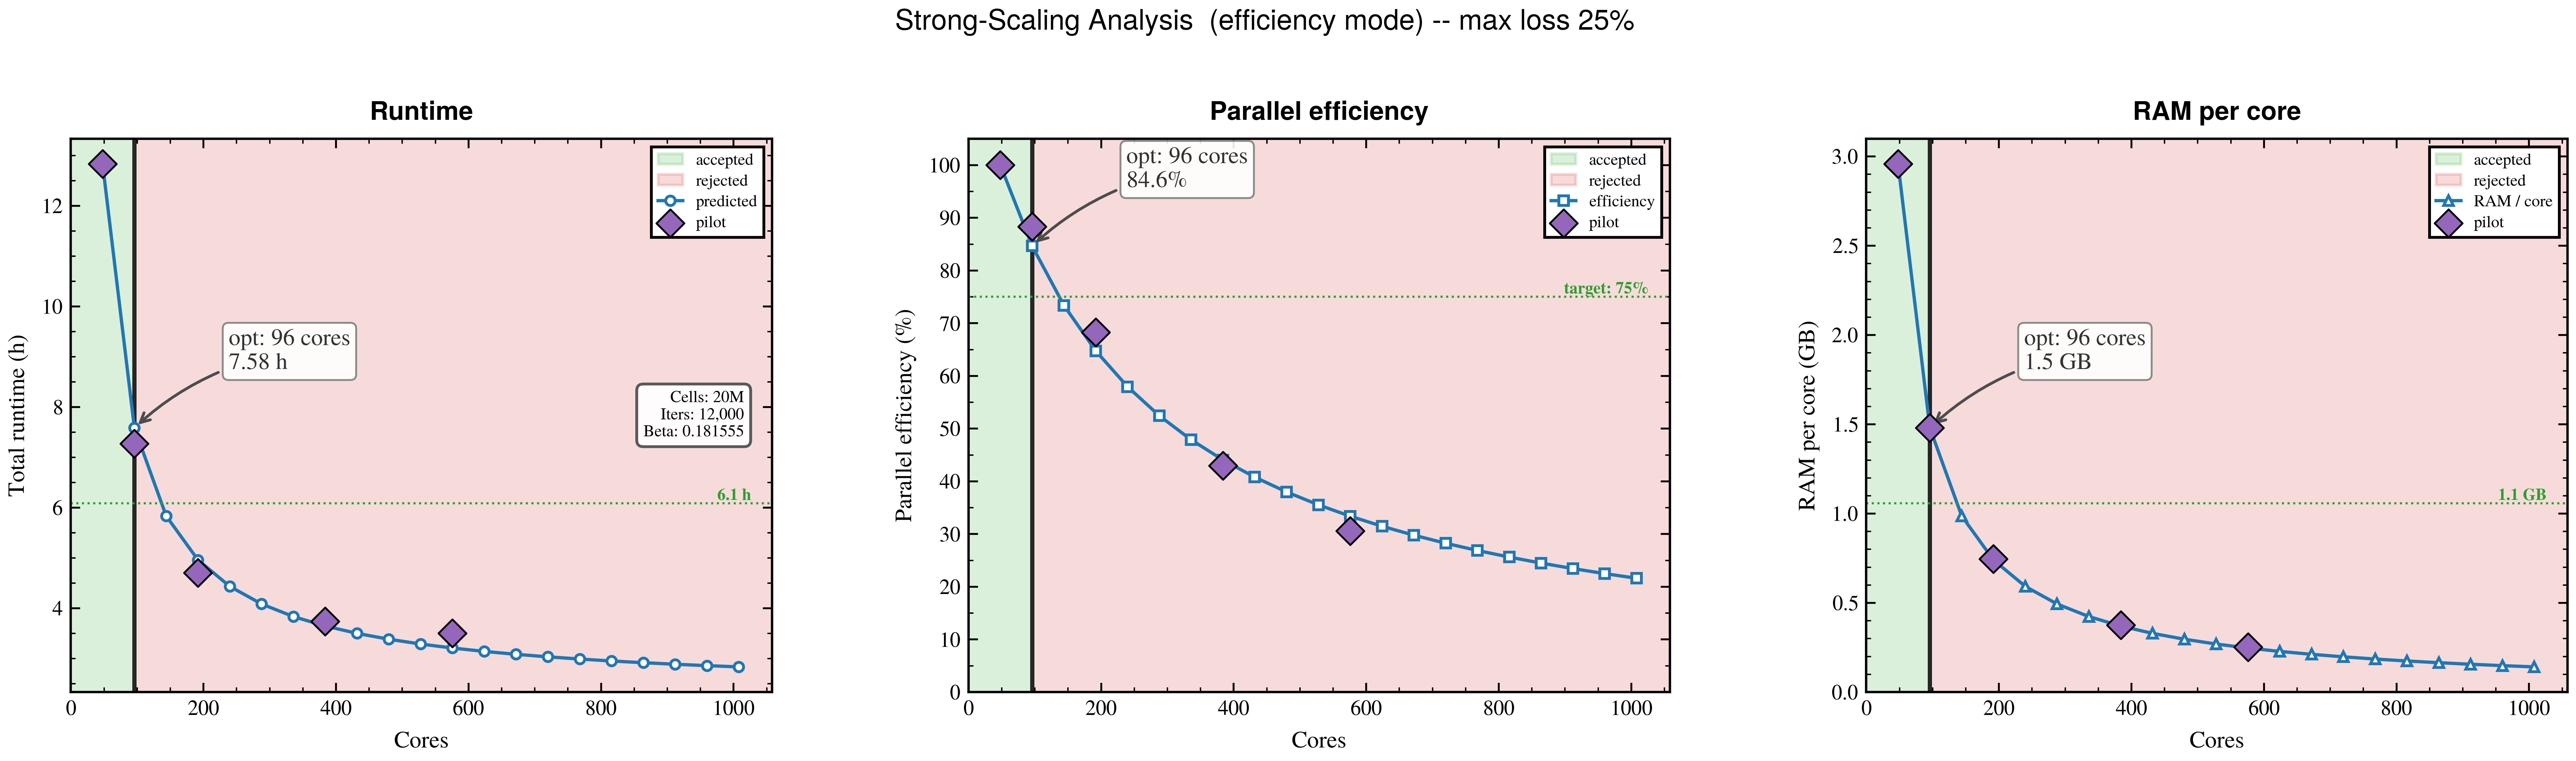

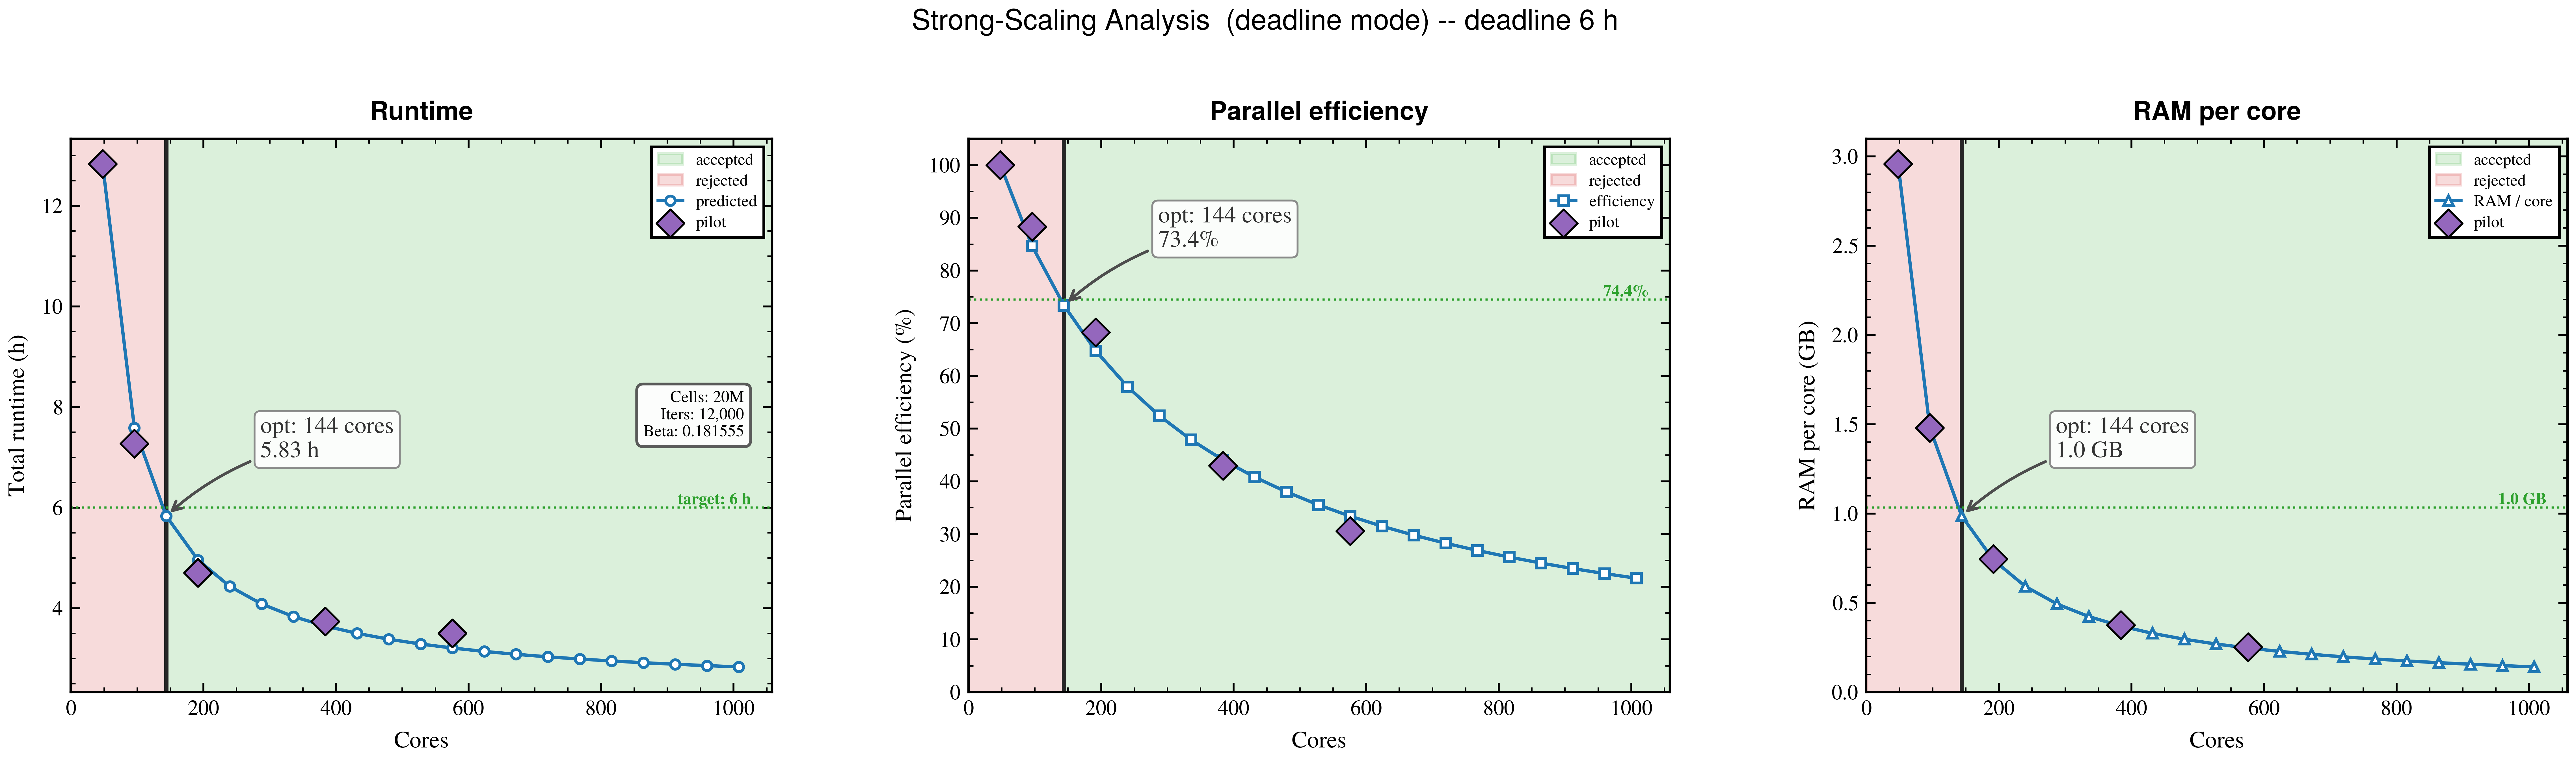

In [23]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from plotting import (
    use_style, new_figure, plot_line, make_legend,
    apply_oldschool_axes, add_reference_lines, add_textbox,
    annotate_point, set_suptitle, set_title,
)
from cfd_perf.optimizer.curve import build_scaling_curve


def _full_curve_and_zones(result, pilot, mesh, params):
    """Build full scaling curve for all cores tested and pilot arrays."""
    nc0 = pilot.baseline_cores
    t0 = pilot.baseline_time_per_iter_s
    n_iter = pilot.n_iterations
    beta = params.beta
    all_cores = sorted(
        set(c.cores for c in result.accepted) | set(r.cores for r in result.rejected)
    )
    if not all_cores:
        return None, None, None, None, None, None, None
    step = all_cores[1] - all_cores[0] if len(all_cores) >= 2 else 1
    nc_range = range(min(all_cores), max(all_cores) + 1, step)
    full = build_scaling_curve(nc_range, params, nc0, t0, n_iter, mesh)
    cores_all = np.array([c.cores for c in full])
    runtime_all = np.array([c.runtime_hours for c in full])
    eff_all = np.array([c.efficiency for c in full]) * 100
    rpc_all = np.array([c.ram_per_core_gb for c in full])

    accepted_cores = [c.cores for c in result.accepted]
    rejected_cores = [r.cores for r in result.rejected]

    pilot_nc = np.array([p.cores for p in pilot.points])
    pilot_runtime_h = np.array([p.time_per_iter_s * pilot.n_iterations / 3600 for p in pilot.points])
    pilot_eff = np.array([
        (t0 * nc0 / (p.time_per_iter_s * p.cores)) * 100 for p in pilot.points
    ])
    pilot_rpc = np.array([p.peak_ram_total_gb / p.cores for p in pilot.points])

    return (cores_all, runtime_all, eff_all, rpc_all,
            accepted_cores, rejected_cores,
            (pilot_nc, pilot_runtime_h, pilot_eff, pilot_rpc))


GREEN = "#009900"
RED = "#CC0000"
ZONE_ALPHA = 0.14


def _hline_label(ax, y_val, label, x_max):
    """Draw a horizontal target line and place the label text at the right end, above it."""
    ax.axhline(y=y_val, color="C2", linewidth=0.9, linestyle=":", zorder=2)
    ax.text(x_max * 0.97, y_val, f"  {label}",
            ha="right", va="bottom", fontsize=7, color="C2", fontweight="bold", zorder=3)


def plot_demo(result, pilot, mesh, params, title_suffix=""):
    use_style("paper")

    out = _full_curve_and_zones(result, pilot, mesh, params)
    if out[0] is None:
        plt.show()
        return
    cores_all, runtime_all, eff_all, rpc_all, accepted_cores, rejected_cores, pilot_data = out
    pilot_nc, pilot_runtime_h, pilot_eff, pilot_rpc = pilot_data

    fig, axes = new_figure(1, 3, figsize=(16, 4.8), constrained_layout=False)
    fig.subplots_adjust(left=0.06, right=0.98, top=0.82, bottom=0.14, wspace=0.28)
    set_suptitle(fig, f"Strong-Scaling Analysis  ({result.mode} mode){title_suffix}", fontsize=12)

    nc_opt = result.optimal.cores if result.optimal else None
    opt = result.optimal
    meta = result.metadata

    x_max = max(cores_all) * 1.05

    # Target thresholds from the optimization call
    target_eff_pct = (1.0 - meta["max_efficiency_loss"]) * 100 if "max_efficiency_loss" in meta else None
    target_deadline_h = meta.get("deadline_hours")

    # Zone logic depends on mode:
    #   efficiency  → accepted = low cores (green left),  rejected = high cores (red right)
    #   deadline    → rejected = low cores (red left),    accepted = high cores (green right)
    if result.mode == "efficiency":
        boundary = max(accepted_cores) if accepted_cores else (min(rejected_cores) if rejected_cores else 0)
        green_span = (0, boundary)
        red_span = (boundary, x_max)
    else:
        boundary = min(accepted_cores) if accepted_cores else (max(rejected_cores) if rejected_cores else x_max)
        red_span = (0, boundary)
        green_span = (boundary, x_max)

    def draw_zones(ax):
        ax.axvspan(*green_span, alpha=ZONE_ALPHA, color=GREEN, zorder=0, label="accepted")
        ax.axvspan(*red_span, alpha=ZONE_ALPHA, color=RED, zorder=0, label="rejected")
        ax.axvline(x=boundary, color="0.15", linewidth=1.8, linestyle="-", zorder=1)

    # Horizontal-line logic:
    #   Find the *exact* (interpolated) core count where the primary target
    #   constraint crosses the curve, then read off runtime / eff / RAM at
    #   that core count so all three panels are consistent.
    if result.mode == "efficiency" and target_eff_pct is not None:
        # eff_all is monotonically decreasing → reverse for np.interp
        nc_at_target = np.interp(target_eff_pct, eff_all[::-1], cores_all[::-1].astype(float))
        h_eff = target_eff_pct
        h_runtime = float(np.interp(nc_at_target, cores_all, runtime_all))
        h_ram = float(np.interp(nc_at_target, cores_all, rpc_all))
        lbl_eff = f"target: {target_eff_pct:.0f}%"
        lbl_rt = f"{h_runtime:.1f} h"
        lbl_ram = f"{h_ram:.1f} GB"
    elif result.mode == "deadline" and target_deadline_h is not None:
        # runtime_all is monotonically decreasing → reverse for np.interp
        nc_at_target = np.interp(target_deadline_h, runtime_all[::-1], cores_all[::-1].astype(float))
        h_runtime = target_deadline_h
        h_eff = float(np.interp(nc_at_target, cores_all, eff_all))
        h_ram = float(np.interp(nc_at_target, cores_all, rpc_all))
        lbl_rt = f"target: {target_deadline_h:.0f} h"
        lbl_eff = f"{h_eff:.1f}%"
        lbl_ram = f"{h_ram:.1f} GB"
    else:
        h_runtime = h_eff = h_ram = None
        lbl_rt = lbl_eff = lbl_ram = ""

    # Runtime
    ax = axes[0]
    set_title(ax, "Runtime")
    ax.set_xlim(0, x_max)
    draw_zones(ax)
    plot_line(ax, cores_all, runtime_all, marker="o", label="predicted", markersize=4)
    ax.scatter(pilot_nc, pilot_runtime_h, marker="D", s=70, color="C4", edgecolors="black", linewidths=0.8, zorder=5, label="pilot")
    if opt:
        add_reference_lines(ax, vlines=[nc_opt], color="C2", linewidth=1.0, linestyle="--")
        annotate_point(ax, f"opt: {nc_opt} cores\n{opt.runtime_hours:.2f} h",
                       xy=(nc_opt, opt.runtime_hours), offset=(40, 25))
    if h_runtime is not None:
        _hline_label(ax, h_runtime, lbl_rt, x_max)
    ax.set_xlabel("Cores"); ax.set_ylabel("Total runtime (h)")
    add_textbox(ax,
                f"Cells: {meta.get('num_cells',0)/1e6:.0f}M\n"
                f"Iters: {meta.get('n_iterations',0):,}\n"
                f"Beta: {meta.get('beta','?')}",
                loc="center right", fontsize=7)
    apply_oldschool_axes(ax, legend=False)
    make_legend(ax, loc="upper right", fontsize=7)

    # Efficiency
    ax = axes[1]
    set_title(ax, "Parallel efficiency")
    ax.set_xlim(0, x_max)
    draw_zones(ax)
    plot_line(ax, cores_all, eff_all, marker="s", label="efficiency", markersize=4)
    ax.scatter(pilot_nc, pilot_eff, marker="D", s=70, color="C4", edgecolors="black", linewidths=0.8, zorder=5, label="pilot")
    if opt:
        add_reference_lines(ax, vlines=[nc_opt], color="C2", linewidth=1.0, linestyle="--")
        annotate_point(ax, f"opt: {nc_opt} cores\n{opt.efficiency * 100:.1f}%",
                      xy=(nc_opt, opt.efficiency * 100), offset=(40, 25))
    if h_eff is not None:
        _hline_label(ax, h_eff, lbl_eff, x_max)
    ax.set_xlabel("Cores"); ax.set_ylabel("Parallel efficiency (%)")
    ax.set_ylim(0, 105)
    ax.yaxis.set_major_locator(plt.MultipleLocator(10))
    ax.yaxis.set_minor_locator(plt.MultipleLocator(5))
    apply_oldschool_axes(ax, legend=False)
    make_legend(ax, loc="upper right", fontsize=7)

    # Memory / core
    ax = axes[2]
    set_title(ax, "RAM per core")
    ax.set_xlim(0, x_max)
    draw_zones(ax)
    plot_line(ax, cores_all, rpc_all, marker="^", label="RAM / core", markersize=4)
    ax.scatter(pilot_nc, pilot_rpc, marker="D", s=70, color="C4", edgecolors="black", linewidths=0.8, zorder=5, label="pilot")
    if opt:
        add_reference_lines(ax, vlines=[nc_opt], color="C2", linewidth=1.0, linestyle="--")
        annotate_point(ax, f"opt: {nc_opt} cores\n{opt.ram_per_core_gb:.1f} GB",
                      xy=(nc_opt, opt.ram_per_core_gb), offset=(40, 25))
    if h_ram is not None:
        _hline_label(ax, h_ram, lbl_ram, x_max)
    ax.set_xlabel("Cores"); ax.set_ylabel("RAM per core (GB)")
    apply_oldschool_axes(ax, legend=False)
    make_legend(ax, loc="upper right", fontsize=7)

    plt.show()


plot_demo(result_eff, pilot, mesh, params, " -- max loss 25%")
plot_demo(result_dl, pilot, mesh, params, " -- deadline 6 h")

## 7. Pilot data overlay

Compare the measured pilot points against the fitted model curve to visualize
the model residuals and non-linear behaviour.

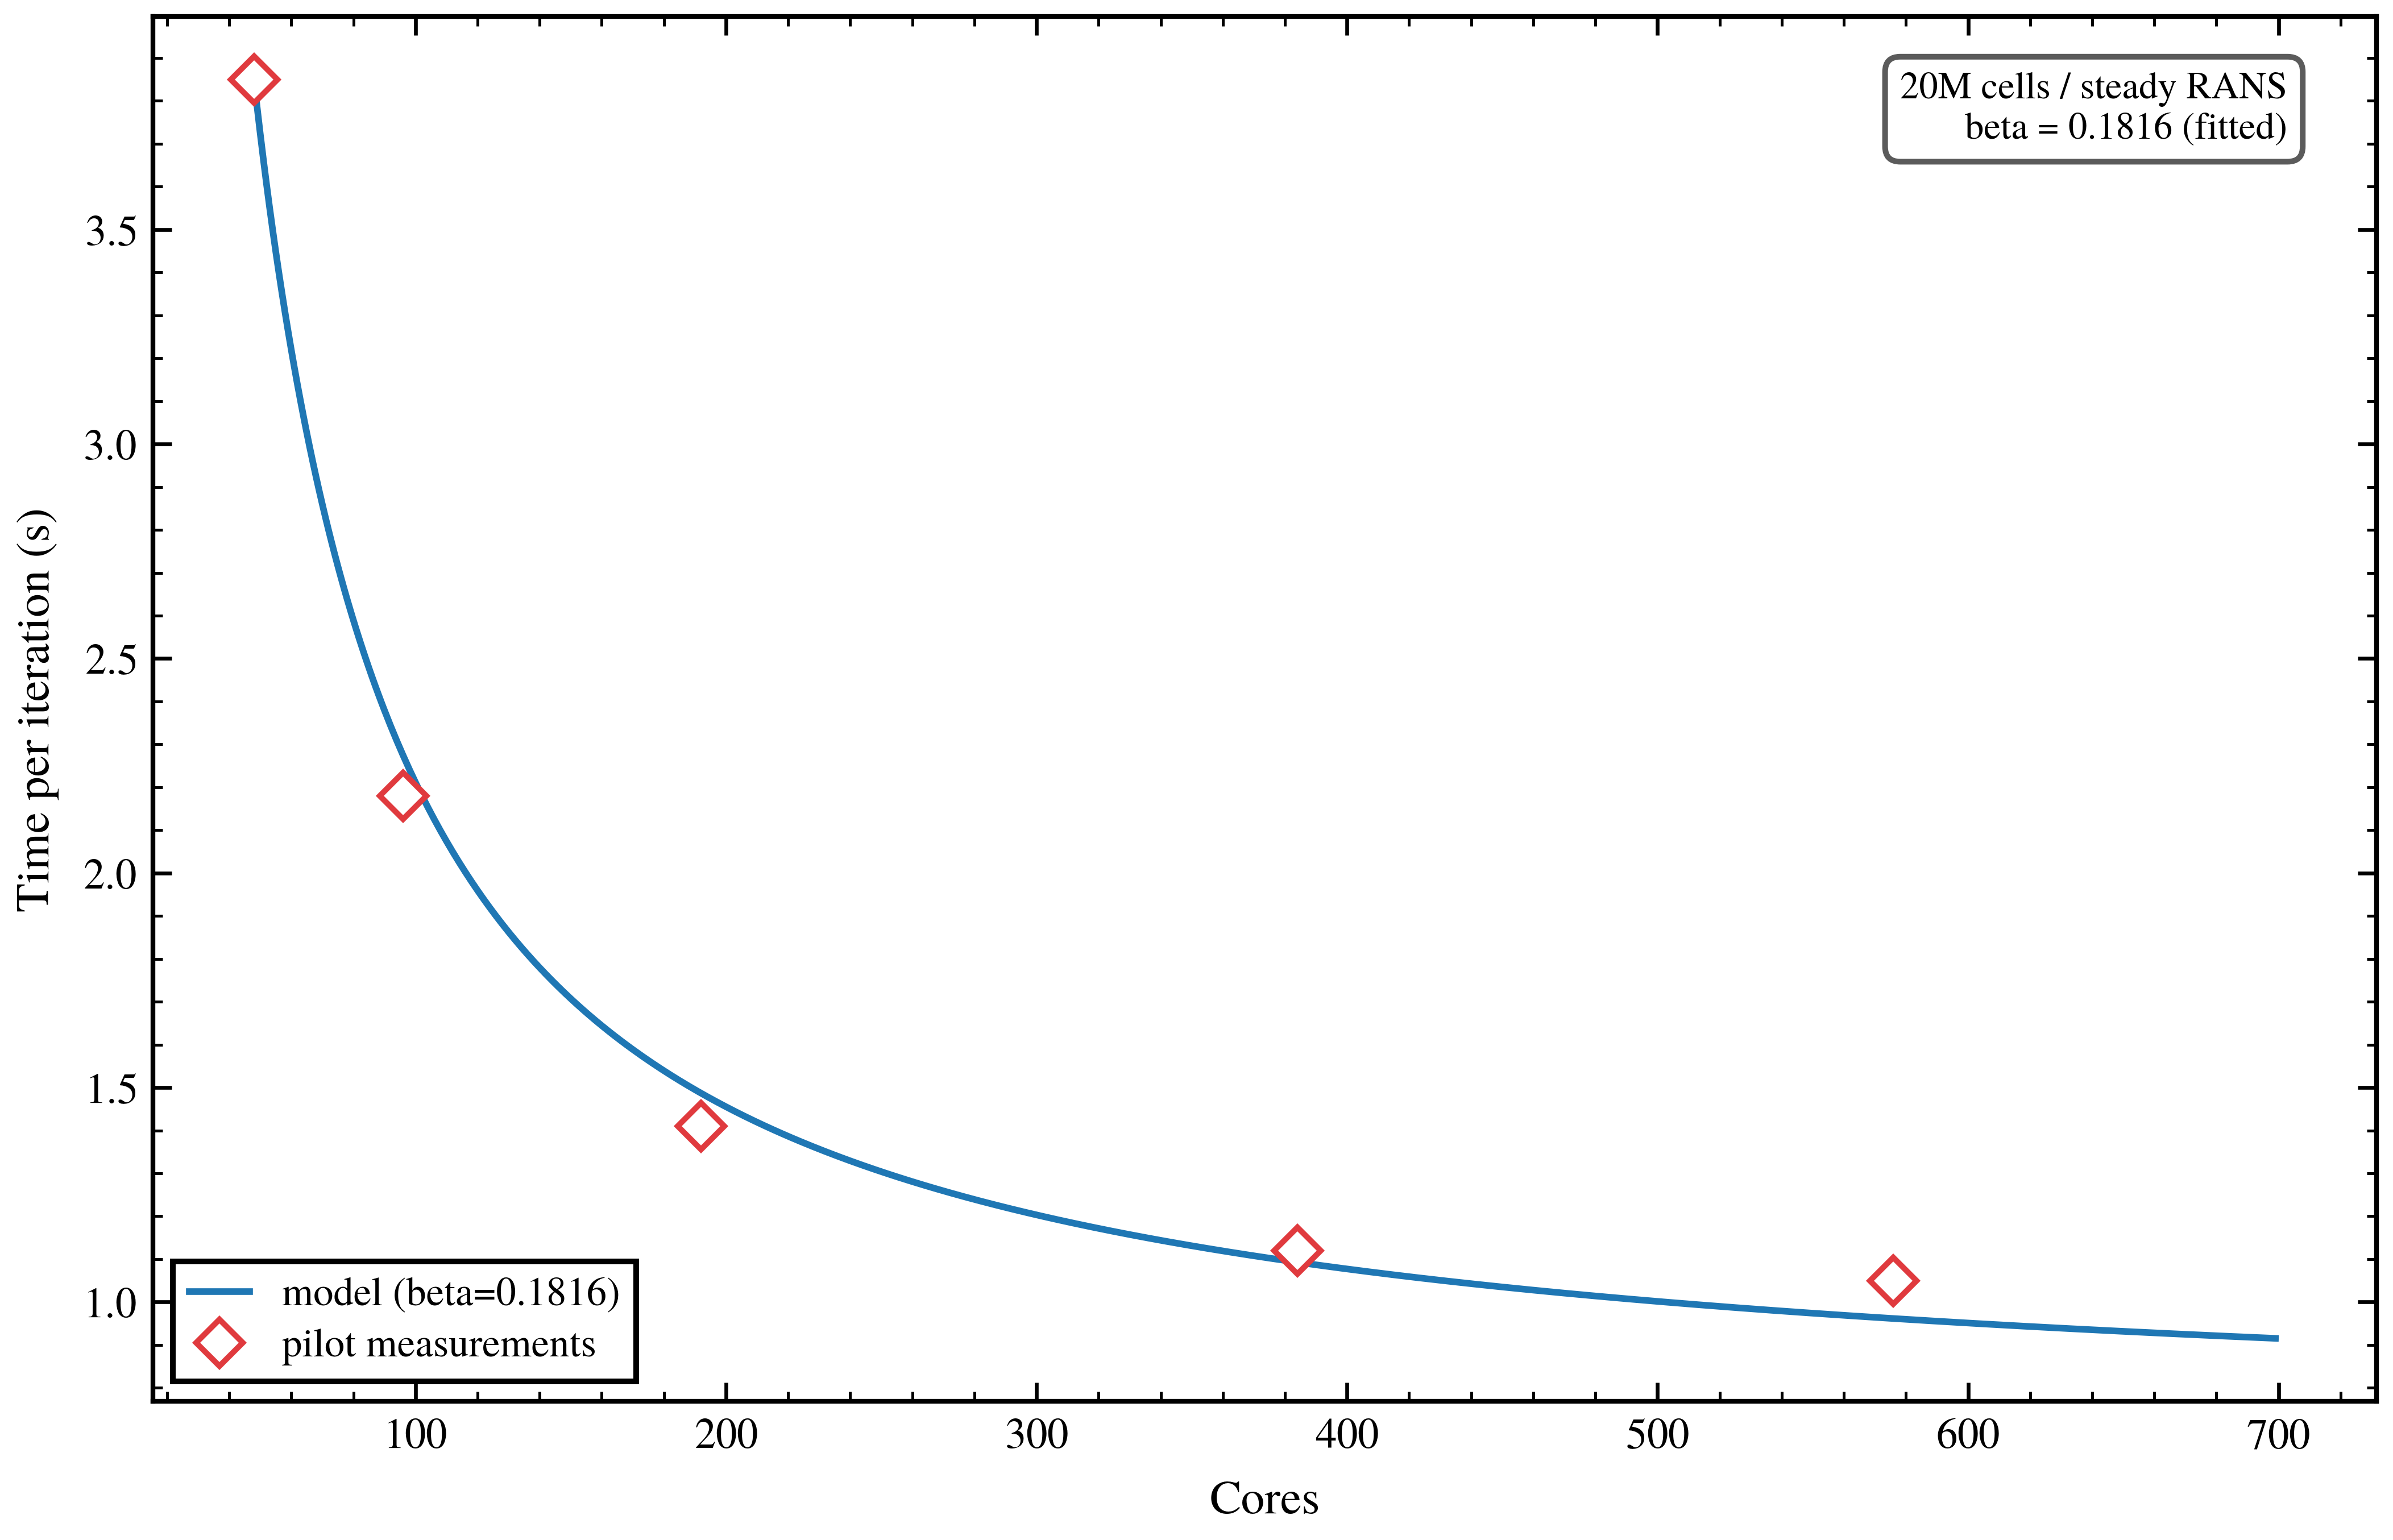

In [24]:
from cfd_perf.models.strong_scaling import time_per_iter

use_style("paper")
fig, ax = new_figure(figsize=(7, 4.5))

nc0 = pilot.baseline_cores
t0 = pilot.baseline_time_per_iter_s
beta = params.beta

nc_dense = np.arange(nc0, 700, 1)
t_model = np.array([time_per_iter(int(nc), nc0, t0, beta) for nc in nc_dense])

plot_line(ax, nc_dense, t_model, marker="", linestyle="-", label=f"model (beta={beta:.4f})")

pilot_nc = np.array([p.cores for p in pilot.points])
pilot_t = np.array([p.time_per_iter_s for p in pilot.points])
plot_line(ax, pilot_nc, pilot_t, marker="D", linestyle="", label="pilot measurements", markersize=7)

ax.set_xlabel("Cores")
ax.set_ylabel("Time per iteration (s)")
add_textbox(ax, f"20M cells / steady RANS\nbeta = {beta:.4f} (fitted)", loc="upper right", fontsize=8)
apply_oldschool_axes(ax)
plt.show()

## 8. Export artifacts

In [25]:
from cfd_perf.io.exporters import export_json, export_csv
from cfd_perf.io.plotting import plot_scaling
from cfd_perf.io.slurm import export_slurm
from plotting import print_file_report

export_json(result_eff, workdir / "result_efficiency.json")
export_csv(result_eff,  workdir / "result_efficiency.csv")
plot_scaling(result_eff, workdir / "scaling_efficiency.png", pilot=pilot, mesh=mesh, params=params)
export_slurm(result_eff, workdir / "submit_eff.sh", job_name="rans_20M", partition="compute")

export_json(result_dl, workdir / "result_deadline.json")
export_csv(result_dl,  workdir / "result_deadline.csv")
plot_scaling(result_dl, workdir / "scaling_deadline.png", pilot=pilot, mesh=mesh, params=params)
export_slurm(result_dl, workdir / "submit_dl.sh", job_name="rans_20M", partition="compute")

exported = sorted([f for f in workdir.iterdir() if not f.name.startswith(".")])
print_file_report(exported, title="Exported artifacts")

              Exported artifacts              
┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━┓
┃ File                   ┃ Format ┃     Size ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━┩
│ mesh.json              │ JSON   │   0.2 kB │
│ pilot.json             │ JSON   │   0.5 kB │
│ result_deadline.csv    │ CSV    │   1.2 kB │
│ result_deadline.json   │ JSON   │   3.1 kB │
│ result_efficiency.csv  │ CSV    │   1.5 kB │
│ result_efficiency.json │ JSON   │   3.6 kB │
│ scaling_deadline.png   │ PNG    │ 161.6 kB │
│ scaling_efficiency.png │ PNG    │ 162.7 kB │
│ submit_dl.sh           │ SH     │   0.1 kB │
│ submit_eff.sh          │ SH     │   0.1 kB │
└────────────────────────┴────────┴──────────┘

## 9. SLURM snippets

In [19]:
from cfd_perf.io.slurm import render_slurm_snippet
from rich.console import Console
from rich.panel import Panel
from rich.syntax import Syntax

console = Console()

for label, result in [("Efficiency mode", result_eff), ("Deadline mode", result_dl)]:
    snippet = render_slurm_snippet(result, job_name="rans_20M", partition="compute")
    console.print(Panel(Syntax(snippet, "bash", theme="monokai"), title=label, border_style="cyan"))

╭──────────────────────────────────────────────── Efficiency mode ────────────────────────────────────────────────╮
│ #!/bin/bash                                                                                                     │
│ #SBATCH --job-name=rans_20M                                                                                     │
│ #SBATCH --partition=compute                                                                                     │
│ #SBATCH --ntasks=96                                                                                             │
│ #SBATCH --time=8:00:00                                                                                          │
│ #SBATCH --mem-per-cpu=1515M                                                                                     │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────── Deadline mode ─────────────────────────────────────────────────╮
│ #!/bin/bash                                                                                                     │
│ #SBATCH --job-name=rans_20M                                                                                     │
│ #SBATCH --partition=compute                                                                                     │
│ #SBATCH --ntasks=144                                                                                            │
│ #SBATCH --time=6:00:00                                                                                          │
│ #SBATCH --mem-per-cpu=1010M                                                                                     │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## 10. CLI equivalent

```bash
cfd-perf analyze mesh.json --pilot pilot.json
cfd-perf fit pilot.json --beta-auto
cfd-perf optimize --mesh mesh.json --pilot pilot.json --max-loss 0.25 --cores-max 1024
cfd-perf optimize --mesh mesh.json --pilot pilot.json --deadline 6h   --cores-max 1024
cfd-perf plot scaling --input result_efficiency.json --out scaling.png
```

Add `--json` to any command for machine-readable output instead of Rich tables.